In [ ]:
# AGENT - CREATION OF COMPLETE PRODUCT
# BOT - IT WILL SHOW US THE SET OF RULES
# USING get_schema( ) FUNCTION
# generate_sql( ) FUNCTION FOR THE QUERY GENARATION
# execute_sql(query) MAINLY USED FOR THE EXECUTION OF THE QUERY


In [1]:
!pip install groq -q
print("GROQ installed successfully")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.3 MB/s eta 0:00:00
GROQ installed successfully


In [2]:
import pandas as pd
import numpy as np
import os
import sqlite3
from groq import Groq
import re

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Summer_Internship_2026/student_performance.csv")
print("=== Data Loaded Successfully ===")

=== Data Loaded Successfully ===


In [5]:
import os
os.environ["GROQ_API_KEY"] = "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"
client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "llama-3.1-8b-instant"
print("Using Model : ",MODEL)


Using Model :  llama-3.1-8b-instant


In [8]:
import io
df = pd.read_csv("/content/drive/MyDrive/Summer_Internship_2026/student_performance.csv")
print("=== Data Loaded Successfully ===")
print("-"*40)
df.head(5)

=== Data Loaded Successfully ===
----------------------------------------


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [9]:
conn = sqlite3.connect('college.db')
df.to_sql("students",conn,if_exists='replace',index=False)
print("DataBase Created Successfully")

DataBase Created Successfully


In [10]:
test_df = pd.read_sql("SELECT count(*) as Total_rows FROM students",conn)
print(f"Verification : {test_df['Total_rows'][0]} rows in database")

Verification : 30 rows in database


In [15]:
# GET SCHEMA
def get_schema(conn,table_name = "students"):
  """ This is the Description for the function of Getting Schema """
  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info ({table_name})")
  columnns = cursor.fetchall()
  schema_lines = [f"Table : {table_name}"]
  for column in columnns:
    schema_lines.append(f"{column[1]} ({column[2]})")
  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows = cursor.fetchall()
  schema_lines.append("Smaple rows (first 3): ")

  for row in sample_rows:
    schema_lines.append(f"{row}")
  return "\n".join(schema_lines)
schema = get_schema(conn)
print(schema )

Table : students
student_id (INTEGER)
name (TEXT)
age (INTEGER)
gender (TEXT)
department (TEXT)
semester (INTEGER)
math_score (INTEGER)
science_score (INTEGER)
english_score (INTEGER)
programming_score (INTEGER)
attendance_percentage (INTEGER)
city (TEXT)
admission_year (INTEGER)
Smaple rows (first 3): 
(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
(1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
(1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [36]:
# GENERATE SCHEMA
def generate_sql(user_question,schema_text,client,model):
  """ THIS IS THE DESCRIPTION FUNCTION FOR GENERATING THE SQL QUERIES """
  system_prompt = f"""You are an expert SQL assisstant .
  You ar connect to Sqlite database with the following structure and You have a 25 years of experience .
  {schema_text}
  Rules you must follow :
  1. Return only SQL query
  2. Do not add explanations
  3. Use only available columns from schema
  4. Generate valid SQLite syntax
  5. Do not include markdown
  """
  response = client.chat.completions.create(
      model = model,
      messages = [
          {"role" : "system","content" :system_prompt},
          {"role" : "user","content" : user_question}
      ],
      temperature = 0.0,
      max_tokens = 500
  )
  sql_query = response.choices[0].message.content.strip()
  return sql_query

question = input("ENTER THE QUESTION : ")
print("\n Generating SQL ...")
sql = generate_sql(question,schema,client,MODEL)
print(f"\n Generated SQl : {sql}")

ENTER THE QUESTION : show all male students with age

 Generating SQL ...

 Generated SQl : SELECT name, age FROM students WHERE gender = 'Male'


In [ ]:
# LOAD CSV AND SQLITE
# GET DATABASE SCHEMA
# GENERATE SQL WITH GROQ
# EXECUTE SQL ON SQLITE
# NATURAL LANGUAGE ANSWER

In [41]:
# function to clean and execute the generated sql query

def execute_sql(sql_query,conn):
  """
    Clean and execute SQL query on SQLite database.

    Parameters:
    sql_query : str
        SQL query generated by LLM

    conn : sqlite3.Connection
        SQLite database connection object

    Returns:
    result_df : pandas.DataFrame
        Query execution result
  """

  clean_sql = re.sub(r'```\S','',sql_query).strip()
  try:
    result_df = pd.read_sql(clean_sql,conn)
    return result_df, None
  except Exception as e:
    return None , str(e)
print(f"Executing SQL : {sql}")
result,error = execute_sql(sql,conn)
if error:
  print(f"Error : {error}")
else:
  print(f"Query returned {len(result)} rows:")
  print(result)

Executing SQL : SELECT name, age FROM students WHERE gender = 'Male'
Query returned 15 rows:
              name  age
0     Aarav Sharma   19
1      Rohit Verma   19
2       Arjun Nair   19
3      Kiran Kumar   21
4     Rahul Mishra   20
5      Vikram Iyer   20
6       Suresh Rao   21
7      Ajay Tiwari   19
8     Manoj Pandey   21
9   Deepak Chauhan   20
10   Harish Pillai   20
11    Sanjay Dubey   21
12       Amit Bose   19
13   Gaurav Shukla   21
14      Nitin Jain   20


Fetching data for plot with SQL: SELECT department, programming_score FROM students


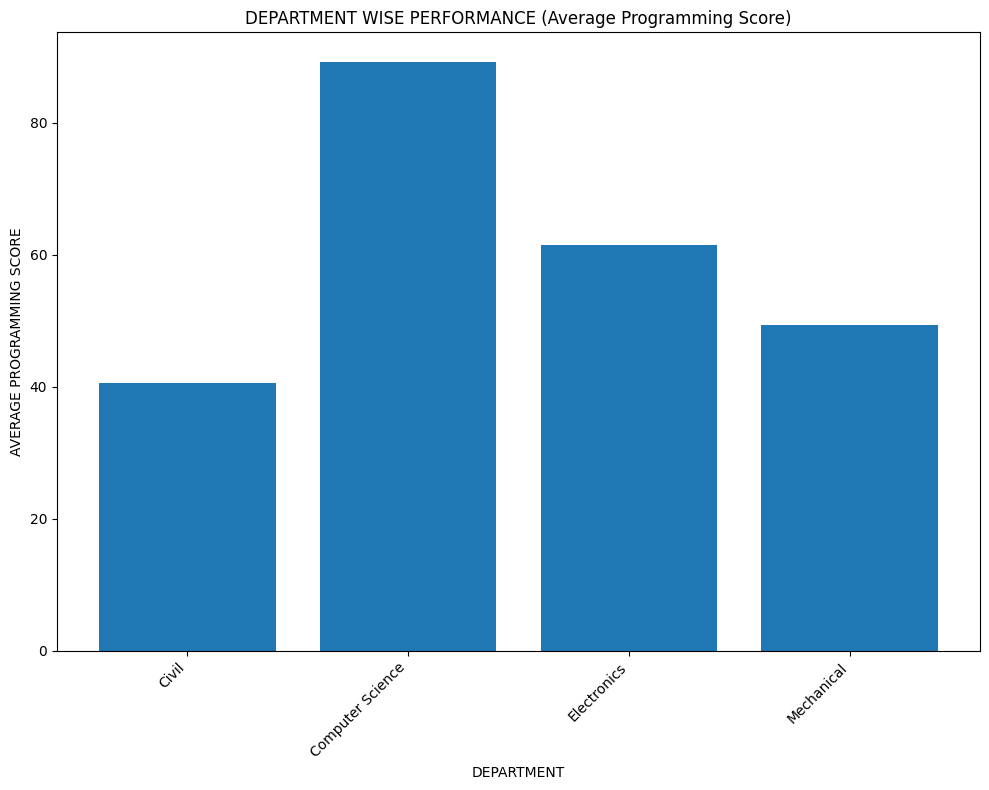

In [44]:
import matplotlib.pyplot as plt

sql_for_plot = "SELECT department, programming_score FROM students"
print(f"Fetching data for plot with SQL: {sql_for_plot}")

# Re-using the execute_sql function from a previous cell
plot_data, error_plot = execute_sql(sql_for_plot, conn)

if error_plot:
  print(f"Error fetching data for plot: {error_plot}")
else:
  # Aggregate programming scores by department (e.g., mean) for the bar chart
  department_scores = plot_data.groupby("department")["programming_score"].mean().reset_index()

  fig , ax = plt.subplots(figsize = (10,8))
  plt.xlabel("DEPARTMENT")
  plt.ylabel("AVERAGE PROGRAMMING SCORE") # Changed label to reflect aggregation
  plt.title("DEPARTMENT WISE PERFORMANCE (Average Programming Score)") # Changed title to reflect aggregation
  plt.bar(department_scores["department"], department_scores["programming_score"])
  plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from overlapping
  plt.show()

In [47]:
def test_to_sql_agent(user_question,conn,client,model,verbose=True):
  """THIS IS THE DESCRIPTION FOR THE FUNCTION TO TEST THE AGENT
     IT TAKE THE USER QUESTION AS A TEXT AND RETURN THE DATABASE FORMAT OF RESULT
     1. GET THE DATABASE SCHEMA
     2. GENERATE THE SQL USING GROQ LLM
     3. EXECUTE SQL ON THE DATABASE
     4. FORMAT AND RETURN RESULT
  """
  print("="*60)
  if verbose:
    print("\n[STEP 1] Reading the DataBase Schema ...")
  schema_text = get_schema(conn)

  if verbose:
    print("Schema Loaded Successfully...")
  if verbose:
    print("\n[STEP 2] Generating SQL query with GROQ LLM...")
  generated_sql = generate_sql(user_question,schema_text,client,model)
  if verbose:
    print(f"Generated SQL : \n {generated_sql}")
  if verbose:
    print("\n [STEP 3] Executing SQL on the database...")
  result_df,error = execute_sql(generated_sql,conn)
  if error:
    print(f"SQL Execution Error : {error}")
    return None,generated_sql
  if verbose:
    print(f"\n [STEP 4] Query returned {len(result_df)} row(s)")
    print("\nRESULTS : ")
    print("-"*40)
    print(result_df.to_string(index=False))
  print("="*40)
  return result_df,generated_sql
question = input("ENTER THE QUESTION : ")
result,sql_used = test_to_sql_agent(
    question,
    conn,
    client,
    MODEL
)



ENTER THE QUESTION : show all the male student with age

[STEP 1] Reading the DataBase Schema ...
Schema Loaded Successfully...

[STEP 2] Generating SQL query with GROQ LLM...
Generated SQL : 
 SELECT name, age FROM students WHERE gender = 'Male'

 [STEP 3] Executing SQL on the database...

 [STEP 4] Query returned 15 row(s)

RESULTS : 
----------------------------------------
          name  age
  Aarav Sharma   19
   Rohit Verma   19
    Arjun Nair   19
   Kiran Kumar   21
  Rahul Mishra   20
   Vikram Iyer   20
    Suresh Rao   21
   Ajay Tiwari   19
  Manoj Pandey   21
Deepak Chauhan   20
 Harish Pillai   20
  Sanjay Dubey   21
     Amit Bose   19
 Gaurav Shukla   21
    Nitin Jain   20


In [48]:
!pip install twilio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.0 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass
from twilio.rest import Client

TW_SID = os.environ.get('TWILIO_SID')
TW_TOKEN = os.environ.get('TWILIO_TOKEN')

if not TW_SID or not TW_TOKEN:
  print("Enter your Twilio Account SID and Auth Token :")
  TW_SID = getpass('Twilio SID : ')
  TW_TOKEN = getpass('Twilio Token : ')
  os.environ['TWILIO_SID'] = TW_SID
  os.environ['TWILIO_TOKEN'] = TW_TOKEN
FROM = 'whatsapp:+14155238886'
TO = input("Enter your WhatsApp Number (e.g +91XXXXXXXXXX) : ").strip()
if not TO.startswith('whatsapp: '):
